## 1. IMPRT IMPORTANT LIBRARIES

In [32]:
import pandas as pd
import numpy as np 
import seaborn as sn

## 2. Load the dataset

In [33]:
import pandas as pd

stroke_data = pd.read_csv(r"C:\Users\USER\Desktop\RUHUHAEXAM\OneDrive\Documentos\Stroke_Prediction\Flask_react_app\backend\healthcare-dataset-stroke-data.csv")



In [34]:
stroke_data.shape

(5110, 12)

In [35]:
stroke_data.head(3)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1


In [36]:

stroke_data.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

### Let's display the unique values of categoricl columns

In [37]:
Categorical_features = [
    'gender', 'hypertension', 'heart_disease', 'ever_married',
    'work_type', 'Residence_type', 'smoking_status', 'stroke'
]

Unique_values = {
    col: stroke_data[col].unique()
    for col in Categorical_features
}
for col ,values in Unique_values.items():print(f"{col}:{values}")

gender:['Male' 'Female' 'Other']
hypertension:[0 1]
heart_disease:[1 0]
ever_married:['Yes' 'No']
work_type:['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type:['Urban' 'Rural']
smoking_status:['formerly smoked' 'never smoked' 'smokes' 'Unknown']
stroke:[1 0]


In [38]:
stroke_data.duplicated().sum()

np.int64(0)

In [39]:
stroke_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [40]:
y=stroke_data['stroke']
y.value_counts(normalize=True)*100


stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

In [41]:
y = stroke_data['stroke']
y.value_counts(normalize=True).mul(100).round(2)


stroke
0    95.13
1     4.87
Name: proportion, dtype: float64

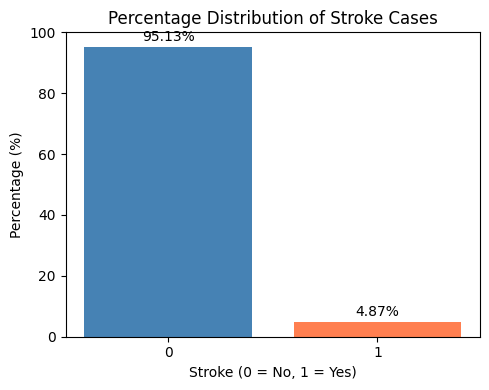

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming y = stroke_data['stroke']
counts_pct = y.value_counts(normalize=True).mul(100).round(2)

# Create bar plot
plt.figure(figsize=(5, 4))
bars = plt.bar(counts_pct.index.astype(str), counts_pct.values, 
               color=['steelblue', 'coral'])
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Percentage (%)')
plt.title('Percentage Distribution of Stroke Cases')
plt.ylim(0, 100)

# Add percentage labels on top of bars
for bar, pct in zip(bars, counts_pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('stroke_percentage.png', dpi=150)
plt.show()

In [12]:
numerical_feactures = ['age','avg_glucose_level','bmi']
stroke_data[numerical_feactures].describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'avg_glucose_level'}>],
       [<Axes: title={'center': 'bmi'}>, <Axes: >]], dtype=object)

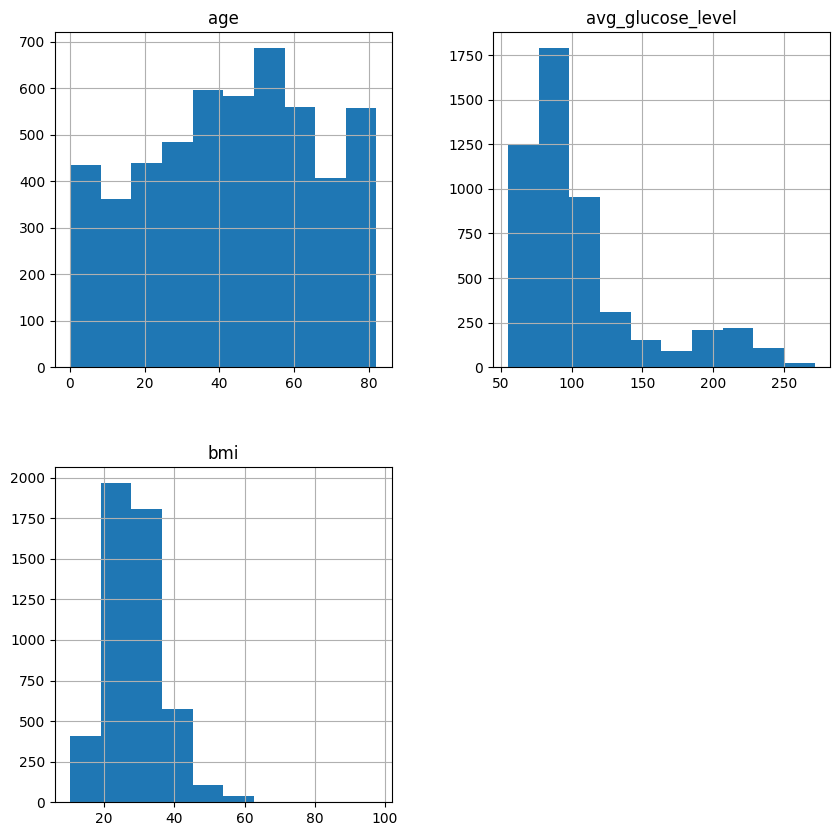

In [13]:
stroke_data[numerical_feactures].hist(figsize=(10, 10))


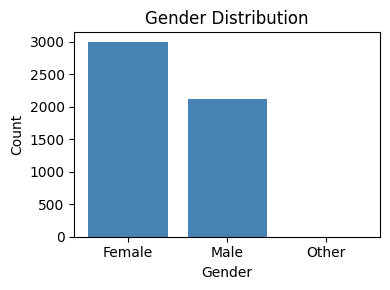

In [49]:
import matplotlib.pyplot as plt

# Count genders
gender_counts = stroke_data['gender'].value_counts()

plt.figure(figsize=(4, 3))
plt.bar(gender_counts.index, gender_counts.values, color='steelblue')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.tight_layout()
plt.savefig('gender_histogram.png', dpi=150)
plt.show()

In [50]:
round(stroke_data[stroke_data['gender'] == 'Male']['stroke'].mean() * 100,2)


np.float64(5.11)

In [15]:
round(stroke_data[stroke_data['gender'] == 'Female']['stroke'].mean() * 100,2)

np.float64(4.71)

### Probability that a person with hypertension have stroke

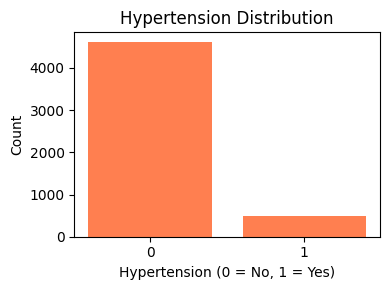

In [51]:
import matplotlib.pyplot as plt

# Count hypertension values (0 and 1)
hypertension_counts = stroke_data['hypertension'].value_counts().sort_index()

plt.figure(figsize=(4, 3))
plt.bar(hypertension_counts.index, hypertension_counts.values, color='coral')
plt.xlabel('Hypertension (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Hypertension Distribution')
plt.xticks([0, 1])
plt.tight_layout()
plt.savefig('hypertension_histogram.png', dpi=150)
plt.show()

In [17]:
round(stroke_data[stroke_data['hypertension'] == 1]['stroke'].mean() * 100,2)

np.float64(13.25)

In [18]:
round(stroke_data[stroke_data['hypertension'] == 0]['stroke'].mean() * 100,2)

np.float64(3.97)

### Probability that a person with heart_disease have stroke

hypertension

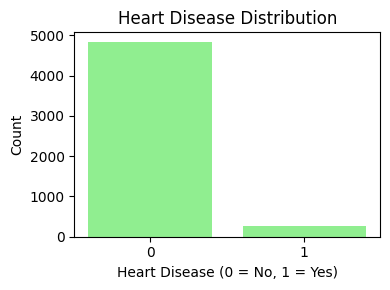

In [52]:
import matplotlib.pyplot as plt

heart_counts = stroke_data['heart_disease'].value_counts().sort_index()

plt.figure(figsize=(4, 3))
plt.bar(heart_counts.index, heart_counts.values, color='lightgreen')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Heart Disease Distribution')
plt.xticks([0, 1])
plt.tight_layout()
plt.savefig('heart_disease_histogram.png', dpi=150)
plt.show()

In [20]:
round(stroke_data[stroke_data['heart_disease'] == 0]['stroke'].mean() * 100,2)

np.float64(4.18)

In [21]:
round(stroke_data[stroke_data['heart_disease'] == 1]['stroke'].mean() * 100,2)

np.float64(17.03)

### Probability that a person with work_type have stroke

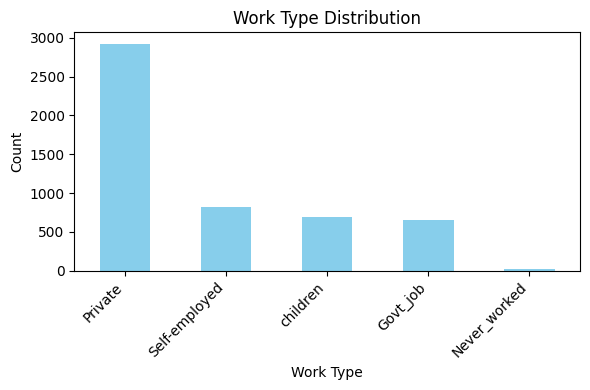

In [53]:
import matplotlib.pyplot as plt

work_counts = stroke_data['work_type'].value_counts()

plt.figure(figsize=(6, 4))
work_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Work Type')
plt.ylabel('Count')
plt.title('Work Type Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('work_type_histogram.png', dpi=150)
plt.show()

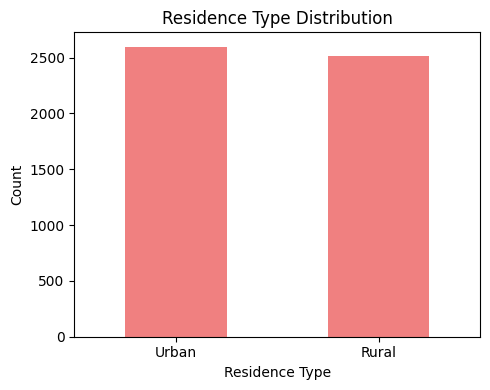

In [55]:
import matplotlib.pyplot as plt

residence_counts = stroke_data['Residence_type'].value_counts()

plt.figure(figsize=(5, 4))
residence_counts.plot(kind='bar', color='lightcoral')
plt.xlabel('Residence Type')
plt.ylabel('Count')
plt.title('Residence Type Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('residence_type_histogram.png', dpi=150)
plt.show()

In [24]:
# Calculate the mean of 'stroke' for each work_type and convert to percentage
stroke_percent_residence_type = stroke_data.groupby('Residence_type')['stroke'].mean() * 100

# Round to 2 decimal places
stroke_percent_residence_type = stroke_percent_residence_type.round(2)

# Display the result
print(stroke_percent_residence_type)


Residence_type
Rural    4.53
Urban    5.20
Name: stroke, dtype: float64


### Probability that a person with smoking_status have stroke

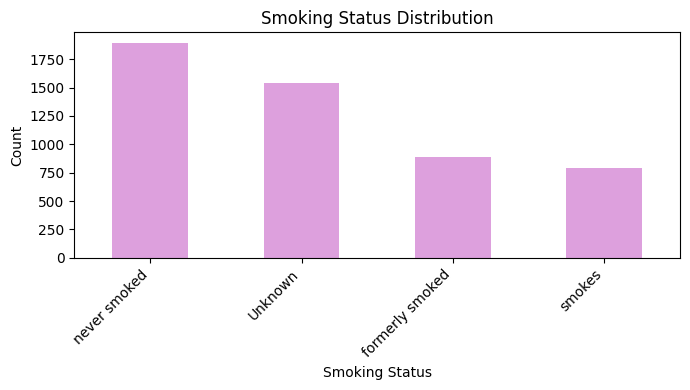

In [56]:
import matplotlib.pyplot as plt

smoking_counts = stroke_data['smoking_status'].value_counts()

plt.figure(figsize=(7, 4))
smoking_counts.plot(kind='bar', color='plum')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.title('Smoking Status Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('smoking_status_histogram.png', dpi=150)
plt.show()

In [26]:
# Calculate the mean of 'stroke' for each work_type and convert to percentage
stroke_percent_smoking_status = stroke_data.groupby('smoking_status')['stroke'].mean() * 100

# Round to 2 decimal places
stroke_percent_smoking_status = stroke_percent_smoking_status.round(2)

# Display the result
print(stroke_percent_smoking_status)


smoking_status
Unknown            3.04
formerly smoked    7.91
never smoked       4.76
smokes             5.32
Name: stroke, dtype: float64


### Probability that a person with ever_married have stroke

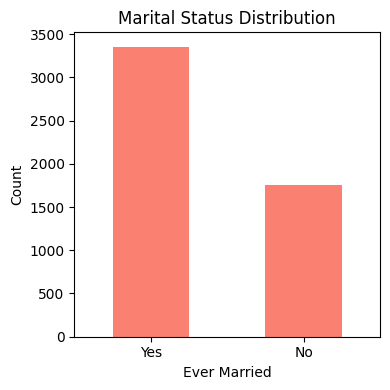

In [57]:
import matplotlib.pyplot as plt

married_counts = stroke_data['ever_married'].value_counts()

plt.figure(figsize=(4, 4))
married_counts.plot(kind='bar', color='salmon')
plt.xlabel('Ever Married')
plt.ylabel('Count')
plt.title('Marital Status Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('ever_married_histogram.png', dpi=150)
plt.show()

In [28]:
round(stroke_data[stroke_data['ever_married'] == 'Yes']['stroke'].mean() * 100,2)

np.float64(6.56)

In [29]:
round(stroke_data[stroke_data['ever_married'] == 'No']['stroke'].mean() * 100,2)

np.float64(1.65)

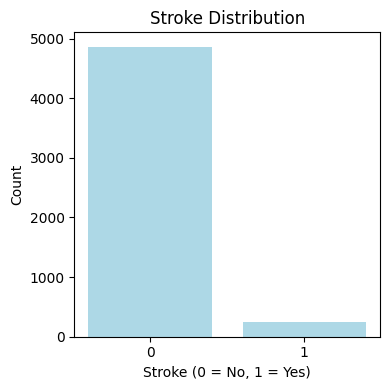

In [58]:
import matplotlib.pyplot as plt

stroke_counts = stroke_data['stroke'].value_counts().sort_index()

plt.figure(figsize=(4, 4))
plt.bar(stroke_counts.index, stroke_counts.values, color='lightblue')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Stroke Distribution')
plt.xticks([0, 1])
plt.tight_layout()
plt.savefig('stroke_histogram.png', dpi=150)
plt.show()

### Understanding the dependance between categorical variable with target variable

In [31]:
from sklearn.metrics import mutual_info_score

categorical_features = [
    'gender',
    'hypertension',
    'heart_disease',
    'ever_married',
    'work_type',
    'Residence_type',   # correct case
    'smoking_status'
]

stroke_data = stroke_data.dropna(
    subset=categorical_features + ['stroke']
)

for col in categorical_features:
    mi = mutual_info_score(stroke_data[col], stroke_data['stroke'])
    print(f"{col}: {mi:.4f}")


gender: 0.0001
hypertension: 0.0060
heart_disease: 0.0059
ever_married: 0.0069
work_type: 0.0068
Residence_type: 0.0001
smoking_status: 0.0028


INTERPRETATION OF RESULT

The mutual information analysis revealed clear differences in how categorical variables contribute to explaining stroke occurrence. Medical conditions, particularly hypertension and heart disease, showed the strongest associations with stroke, confirming their critical role as key risk factors. Variables related to lifestyle and social context, such as work type, smoking status, and marital status, demonstrated weaker but non-negligible relationships, suggesting they provide supportive contextual information rather than direct predictive power. In contrast, gender exhibited a very weak association, while residence type (urban or rural) showed almost no relationship with stroke, indicating minimal relevance for prediction. Overall, the results highlight that clinical health factors are far more informative than demographic or residential characteristics in predicting stroke, providing a strong basis for prioritizing feature selection in subsequent modeling.


1. There is a weak positive relationship between age and stroke risk (correlation ≈ 0.25).
2. Glucose levels show a slight difference between individuals with stroke and those without, but no significant relationship was found.
3. BMI shows no significant relationship with stroke risk.
4. Hypertension significantly increases stroke risk (odds ratio ≈ 3.30×).
5. Males are slightly more likely to have a stroke than females.
6. Heart disease significantly increases stroke risk (odds ratio ≈ 4.07×).
7. Married individuals are more likely to have a stroke compared to unmarried individuals.
8. Self-employed individuals have a higher probability of stroke compared to other employment types.
9. Rural residents are slightly more likely to have a stroke than urban residents, but the difference is small and not strongly significant.
10. Smoking shows little to no significant difference in stroke risk between smokers and non-smokers in this analysis.